# TabTransformer — Modelo tabular con embeddings y atención (L1, L2, L3)

**Arquitectura:** TabTransformer (Huang et al., 2020) — embeddings por feature categórica → Transformer Encoder → concatenación con features continuas → MLP.
**Features categóricas:** `acuity` (1-5) + `chiefcomplaint` (top 200 categorías).
**Features continuas:** 6 vitales de triage + `n_medications` (7 en total).
**Salidas:** modelos en `models/tabtransformer/<timestamp>/tabtransformer_{L1,L2,L3}.pt` + tabla comparativa.

El TabTransformer aprovecha la atención multi-cabeza para capturar interacciones entre features categóricas codificadas como embeddings. Se evalúa si el aprendizaje de representaciones enriquecidas de `acuity` y `chiefcomplaint` aporta ventaja sobre la codificación por target encoding de CatBoost.

## 1. Setup

Importaciones y configuración de reproducibilidad. Se fijan semillas en NumPy, PyTorch y cuDNN. El device se selecciona automáticamente (CUDA si está disponible, CPU en caso contrario).

In [1]:
import os
import copy
import json
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dotenv import load_dotenv
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

load_dotenv(dotenv_path=Path("../../.env"), override=True)
if not os.getenv("MIMIC_IV_ED_PATH"):
    load_dotenv(dotenv_path=Path(".env"), override=True)

DATA          = Path(os.getenv("MIMIC_IV_ED_PATH", ""))
PROCESSED_DIR = Path("../../data/processed")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

TARGETS = ["L1", "L2", "L3"]
TARGET_NAMES = {
    "L1": "Ingreso hospitalario",
    "L2": "Resultado crítico en urgencias",
    "L3": "Intervención crítica en urgencias",
}

Device: cpu
PyTorch: 2.11.0+cpu


## 2. Carga de datos

Se cargan las particiones de train y validación. `n_medications` se agrega desde `medrecon` con el mismo procedimiento que en los notebooks anteriores para garantizar consistencia entre modelos.

In [ ]:
df_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
df_val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")

# n_medications desde medrecon — mismo cálculo que en los notebooks anteriores
df_medrecon = pd.read_csv(DATA / "medrecon.csv", low_memory=False, usecols=["stay_id"])
n_meds = df_medrecon.groupby("stay_id").size().rename("n_medications").reset_index()
for df in [df_train, df_val]:
    df.drop(columns=["n_medications"], errors="ignore", inplace=True)
df_train = df_train.merge(n_meds, on="stay_id", how="left")
df_val   = df_val.merge(n_meds, on="stay_id", how="left")
df_train["n_medications"] = df_train["n_medications"].fillna(0).astype(int)
df_val["n_medications"]   = df_val["n_medications"].fillna(0).astype(int)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,}")
print(f"Columnas: {list(df_train.columns)}")

## 3. Codificación de features categóricas

TabTransformer requiere índices enteros para construir los embeddings:
- **`acuity`** (1–5): índices 1–5; 0 reservado para NaN.
- **`chiefcomplaint`** (top 200): índices 1–200; 0 = NaN/vacío; 201 = otras categorías.

El vocabulario de `chiefcomplaint` se construye exclusivamente desde el conjunto de entrenamiento para evitar data leakage.

In [ ]:
def encode_acuity(series: pd.Series) -> np.ndarray:
    """NaN → 0, valores 1-5 se mantienen. Clamp para evitar índices fuera de rango."""
    s = series.fillna(0).astype(int).clip(0, 5)
    return s.values.astype(np.int64)

ACUITY_VOCAB_SIZE = 6  # índices 0..5

# Vocabulario chiefcomplaint construido exclusivamente desde train para evitar data leakage
CHIEFCOMPLAINT_TOP_N = 200

cc_counts = (
    df_train["chiefcomplaint"]
    .fillna("")
    .str.lower()
    .str.strip()
    .value_counts()
)
top_cc    = cc_counts.head(CHIEFCOMPLAINT_TOP_N).index.tolist()
cc_vocab  = {cc: i + 1 for i, cc in enumerate(top_cc)}  # 1..200
CC_OOV    = CHIEFCOMPLAINT_TOP_N + 1   # 201
CC_VOCAB_SIZE = CHIEFCOMPLAINT_TOP_N + 2  # 0=NaN, 1..200=top, 201=other

def encode_chiefcomplaint(series: pd.Series, vocab: dict) -> np.ndarray:
    out = []
    for val in series:
        if pd.isna(val) or str(val).strip() == "":
            out.append(0)
        else:
            out.append(vocab.get(str(val).lower().strip(), CC_OOV))
    return np.array(out, dtype=np.int64)

# Vocabulario arrival_transport construido desde train
at_counts = (
    df_train["arrival_transport"]
    .fillna("desconocido")
    .str.lower()
    .str.strip()
    .value_counts()
)
at_vocab      = {v: i + 1 for i, v in enumerate(at_counts.index.tolist())}
AT_OOV        = len(at_vocab) + 1
AT_VOCAB_SIZE = len(at_vocab) + 2  # 0=NaN, 1..N=categorías conocidas, N+1=other

def encode_arrival_transport(series: pd.Series, vocab: dict) -> np.ndarray:
    out = []
    for val in series:
        if pd.isna(val) or str(val).strip() == "":
            out.append(0)
        else:
            out.append(vocab.get(str(val).lower().strip(), AT_OOV))
    return np.array(out, dtype=np.int64)

acuity_train = encode_acuity(df_train["acuity"])
acuity_val   = encode_acuity(df_val["acuity"])
cc_train     = encode_chiefcomplaint(df_train["chiefcomplaint"], cc_vocab)
cc_val       = encode_chiefcomplaint(df_val["chiefcomplaint"],   cc_vocab)
at_train     = encode_arrival_transport(df_train["arrival_transport"], at_vocab)
at_val       = encode_arrival_transport(df_val["arrival_transport"],   at_vocab)

X_cat_train = np.stack([acuity_train, cc_train, at_train], axis=1)  # (n, 3)
X_cat_val   = np.stack([acuity_val,   cc_val,   at_val],   axis=1)

CAT_DIMS  = [ACUITY_VOCAB_SIZE, CC_VOCAB_SIZE, AT_VOCAB_SIZE]
CAT_NAMES = ["acuity", "chiefcomplaint", "arrival_transport"]

print(f"X_cat_train: {X_cat_train.shape}")
print(f"acuity        — únicos: {np.unique(acuity_train)}")
print(f"chiefcc       — únicos: {len(np.unique(cc_train))} | max índice: {cc_train.max()}")
print(f"arrival_trans — únicos: {np.unique(at_train)}")
print(f"CAT_DIMS: {CAT_DIMS}")

## 4. Features continuas

Imputación con la mediana y escalado Z-score ajustados exclusivamente sobre train. Las 7 features continuas (`temperature`, `heartrate`, `resprate`, `o2sat`, `sbp`, `dbp`, `n_medications`) se procesan de forma independiente a las categóricas.

In [ ]:
CONT_FEATURES = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "n_medications", "pain"]

imputer_c = SimpleImputer(strategy="median")
scaler_c  = StandardScaler()
X_cont_train = scaler_c.fit_transform(
    imputer_c.fit_transform(df_train[CONT_FEATURES])
).astype(np.float32)
X_cont_val = scaler_c.transform(
    imputer_c.transform(df_val[CONT_FEATURES])
).astype(np.float32)

print(f"X_cont_train: {X_cont_train.shape} | X_cont_val: {X_cont_val.shape}")
print(f"Features continuas: {CONT_FEATURES}")

## 5. Dataset y modelo TabTransformer

`TriageTabDataset` empaqueta los índices enteros de features categóricas, las features continuas y las etiquetas. La clase `TabTransformer` implementa la arquitectura completa: embeddings por feature categórica, TransformerEncoder con Pre-LayerNorm, y MLP head con GELU.

In [5]:
class TriageTabDataset(Dataset):
    def __init__(self, X_cat: np.ndarray, X_cont: np.ndarray, y: np.ndarray):
        self.X_cat  = torch.LongTensor(X_cat)
        self.X_cont = torch.FloatTensor(X_cont)
        self.y      = torch.FloatTensor(y)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_cont[idx], self.y[idx]

In [6]:
class TabTransformer(nn.Module):
    """
    TabTransformer (Huang et al., 2020 — arXiv:2012.06678).

    Pipeline:
      1. Cada feature categórica → embedding (misma dim D para el transformer).
      2. Secuencia de embeddings (n_cat, D) → TransformerEncoder (Pre-LN).
      3. Aplanar salida del transformer → concatenar con features continuas.
      4. MLP head → logit escalar.

    Args:
        cat_dims:             lista con num_embeddings por feature categórica.
        n_continuous:         número de features continuas.
        embed_dim:            dimensión D de los embeddings (común a todas las categóricas).
        n_heads:              cabezas de atención (debe dividir embed_dim).
        n_transformer_layers: capas del TransformerEncoder.
        mlp_hidden:           unidades en la primera capa oculta del MLP.
        dropout:              tasa de dropout (transformer + MLP).
    """
    def __init__(
        self,
        cat_dims: list,
        n_continuous: int,
        embed_dim: int = 32,
        n_heads: int = 4,
        n_transformer_layers: int = 3,
        mlp_hidden: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        # Embedding por feature categórica; padding_idx=0 → vector cero para NaN
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=embed_dim, padding_idx=0)
            for dim in cat_dims
        ])
        # TransformerEncoder con Pre-LayerNorm (más estable en pocos pasos)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=4 * embed_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_transformer_layers)
        # MLP head
        n_cat     = len(cat_dims)
        input_dim = n_cat * embed_dim + n_continuous
        self.mlp = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden // 2, 1),
        )

    def forward(self, x_cat: torch.Tensor, x_cont: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x_cat:  (batch, n_cat)  — índices enteros.
            x_cont: (batch, n_cont) — features continuas normalizadas.
        Returns:
            (batch,) logit (sin sigmoid; usar BCEWithLogitsLoss).
        """
        # Stack embeddings → (batch, n_cat, embed_dim)
        embeds = torch.stack(
            [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1
        )
        # Transformer encoder
        transformed = self.transformer(embeds)        # (batch, n_cat, embed_dim)
        cat_out     = transformed.flatten(start_dim=1)  # (batch, n_cat * embed_dim)
        # Concatenar con features continuas
        combined = torch.cat([cat_out, x_cont], dim=1)
        return self.mlp(combined).squeeze(1)

## 6. Funciones de entrenamiento y evaluación

`train_epoch` ejecuta un paso de optimización completo con gradient clipping (max_norm=1.0). `evaluate` calcula las probabilidades predichas sin actualizar gradientes y las devuelve como arrays NumPy para el cálculo de métricas con scikit-learn.

In [7]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    for X_cat, X_cont, y in loader:
        X_cat, X_cont, y = X_cat.to(device), X_cont.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X_cat, X_cont)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):
    model.eval()
    all_probs, all_y = [], []
    for X_cat, X_cont, y in loader:
        logits = model(X_cat.to(device), X_cont.to(device))
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_y)

## 7. Entrenamiento multi-label: L1, L2, L3

**Hiperparámetros:**
- `embed_dim=32`, `n_heads=4` (32/4=8 dim/head), `n_transformer_layers=3`
- MLP hidden=128, GELU, dropout=0.1
- Adam lr=1e-3, weight_decay=1e-5 (regularización L2 para el transformer)
- ReduceLROnPlateau (patience=3, factor=0.5), early stopping patience=7
- BCEWithLogitsLoss con pos_weight dinámico

In [ ]:
EMBED_DIM             = 32
N_HEADS               = 4
N_TRANSFORMER_LAYERS  = 3
MLP_HIDDEN            = 128
DROPOUT               = 0.1
LR                    = 1e-3
WEIGHT_DECAY          = 1e-5
BATCH_SIZE            = 512
MAX_EPOCHS            = 30
PATIENCE              = 7

final_results = {}
final_models  = {}
history       = {}

for target in TARGETS:
    y_tr = df_train[target].values.astype(np.float32)
    y_v  = df_val[target].values.astype(np.float32)
    pos_weight = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))

    print(f"\n{'='*65}")
    print(f"TARGET: {target} — {TARGET_NAMES[target]}")
    print(f"Prevalencia train: {y_tr.mean()*100:.2f}%  |  pos_weight: {pos_weight:.1f}")
    print(f"{'='*65}")

    train_ds = TriageTabDataset(X_cat_train, X_cont_train, y_tr)
    val_ds   = TriageTabDataset(X_cat_val,   X_cont_val,   y_v)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=2048,       shuffle=False, num_workers=0)

    model = TabTransformer(
        cat_dims=CAT_DIMS,
        n_continuous=len(CONT_FEATURES),
        embed_dim=EMBED_DIM,
        n_heads=N_HEADS,
        n_transformer_layers=N_TRANSFORMER_LAYERS,
        mlp_hidden=MLP_HIDDEN,
        dropout=DROPOUT,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=device)
    )
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5
    )

    best_auroc = 0.0
    best_state = None
    wait       = 0
    hist       = []

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss = train_epoch(model, train_dl, optimizer, criterion, device)
        y_prob, y_true = evaluate(model, val_dl, device)
        val_auroc = roc_auc_score(y_true, y_prob)
        scheduler.step(val_auroc)
        hist.append({"epoch": epoch, "loss": tr_loss, "auroc": val_auroc})
        print(f"  Epoch {epoch:02d} | loss={tr_loss:.4f} | val_AUROC={val_auroc:.4f}"
              f"  {'*' if val_auroc > best_auroc else ''}")

        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"  Early stopping en epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    y_prob, y_true = evaluate(model, val_dl, device)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    print(f"\n  Mejor modelo — AUROC: {auroc:.4f} | AUPRC: {auprc:.4f} | Brier: {brier:.4f}")
    final_results[target] = {"AUROC": auroc, "AUPRC": auprc, "Brier": brier,
                              "Prev_val": float(y_v.mean())}
    final_models[target]  = model
    history[target]       = hist

print("\nEntrenamiento completado para L1, L2 y L3.")

## 8. Curvas de entrenamiento

Evolución del loss en train y del AUROC en validación por época para cada target. Una divergencia entre ambas curvas indicaría sobreajuste; la convergencia del AUROC valida el punto de early stopping seleccionado.

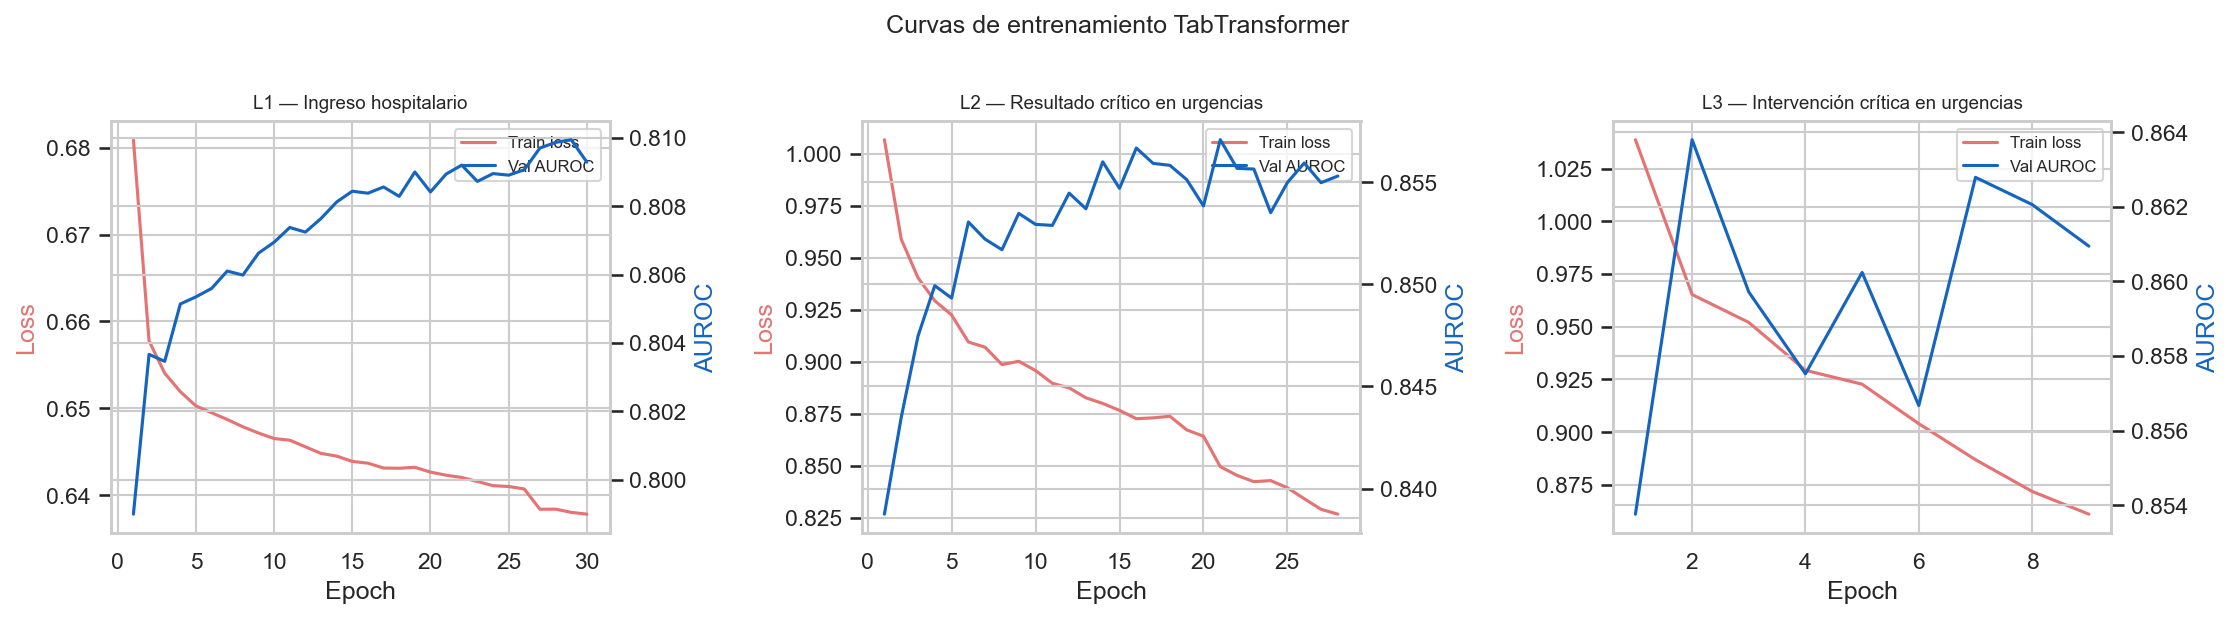

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axes, TARGETS):
    hist_df = pd.DataFrame(history[target])
    ax2 = ax.twinx()
    ax.plot(hist_df["epoch"], hist_df["loss"],  color="#E57373", label="Train loss")
    ax2.plot(hist_df["epoch"], hist_df["auroc"], color="#1565C0", label="Val AUROC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss",  color="#E57373")
    ax2.set_ylabel("AUROC", color="#1565C0")
    ax.set_title(f"{target} — {TARGET_NAMES[target]}", fontsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.suptitle("Curvas de entrenamiento TabTransformer", y=1.02)
plt.tight_layout()
plt.show()

## 9. Tabla comparativa: LogReg vs CatBoost vs LSTM vs TabTransformer

El TabTransformer obtiene un AUROC intermedio entre LogReg y CatBoost para L1, pero queda por debajo de los demás modelos en L2 y L3. La arquitectura basada en atención no compensa la ventaja de CatBoost para features categóricas de alta cardinalidad con este tamaño de dataset.

In [10]:
# Resultados previos (notebooks 01, 02/03, 04)
logreg_results = {
    "L1": {"AUROC": 0.8048, "AUPRC": 0.7102, "Brier": 0.1812},
    "L2": {"AUROC": 0.8617, "AUPRC": 0.0962, "Brier": 0.1596},
    "L3": {"AUROC": 0.8773, "AUPRC": 0.0705, "Brier": 0.1383},
}
catboost_results = {
    "L1": {"AUROC": 0.8314, "AUPRC": 0.7523, "Brier": 0.1684},
    "L2": {"AUROC": 0.8795, "AUPRC": 0.2228, "Brier": 0.1336},
    "L3": {"AUROC": 0.8943, "AUPRC": 0.1141, "Brier": 0.1046},
}
lstm_results = {
    "L1": {"AUROC": 0.7905, "AUPRC": 0.7056, "Brier": 0.1877},
    "L2": {"AUROC": 0.8732, "AUPRC": 0.1251, "Brier": 0.1445},
    "L3": {"AUROC": 0.8987, "AUPRC": 0.1325, "Brier": 0.0865},
}

rows = []
for target in TARGETS:
    lr   = logreg_results[target]
    cb   = catboost_results[target]
    lstm = lstm_results[target]
    tabt = final_results[target]
    rows.append({
        "Target":          target,
        "LogReg_AUROC":    lr["AUROC"],
        "CatBoost_AUROC":  cb["AUROC"],
        "LSTM_AUROC":      lstm["AUROC"],
        "TabTrans_AUROC":  tabt["AUROC"],
        "LogReg_AUPRC":    lr["AUPRC"],
        "CatBoost_AUPRC":  cb["AUPRC"],
        "LSTM_AUPRC":      lstm["AUPRC"],
        "TabTrans_AUPRC":  tabt["AUPRC"],
        "LogReg_Brier":    lr["Brier"],
        "CatBoost_Brier":  cb["Brier"],
        "LSTM_Brier":      lstm["Brier"],
        "TabTrans_Brier":  tabt["Brier"],
    })

df_comp = pd.DataFrame(rows).set_index("Target")
print("=== LogReg vs CatBoost (Optuna) vs LSTM vs TabTransformer — Validación ===")
print(df_comp.round(4).to_string())

=== LogReg vs CatBoost (Optuna) vs LSTM vs TabTransformer — Validación ===
        LogReg_AUROC  CatBoost_AUROC  LSTM_AUROC  TabTrans_AUROC  LogReg_AUPRC  CatBoost_AUPRC  LSTM_AUPRC  TabTrans_AUPRC  LogReg_Brier  CatBoost_Brier  LSTM_Brier  TabTrans_Brier
Target                                                                                                                                                                              
L1            0.8048          0.8314      0.7905          0.8099        0.7102          0.7523      0.7056          0.7192        0.1812          0.1684      0.1877          0.1786
L2            0.8617          0.8795      0.8732          0.8571        0.0962          0.2228      0.1251          0.1056        0.1596          0.1336      0.1445          0.1597
L3            0.8773          0.8943      0.8987          0.8638        0.0705          0.1141      0.1325          0.0667        0.1383          0.1046      0.0865          0.1172


## 10. Guardado de modelos

Se persisten los pesos del modelo (`.pt`), las métricas, la configuración arquitectónica y el vocabulario de `chiefcomplaint` en `models/tabtransformer/<timestamp>/`. Los preprocesadores se guardan en `preprocessors.pkl` para reproducir las transformaciones en test y eICU.

In [ ]:
TIMESTAMP  = datetime.now().strftime("%Y%m%d_%H%M%S")
MODELS_DIR = Path("../../models/tabtransformer") / TIMESTAMP
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Pesos de los modelos
for target, model in final_models.items():
    path = MODELS_DIR / f"tabtransformer_{target}.pt"
    torch.save(model.state_dict(), path)
    print(f"Guardado: {path}")

# Métricas
with open(MODELS_DIR / "results.json", "w") as f:
    json.dump(final_results, f, indent=2)

# Config del modelo + vocabularios de categóricas
model_config = {
    "cat_dims":             CAT_DIMS,
    "cat_names":            CAT_NAMES,
    "cont_features":        CONT_FEATURES,
    "embed_dim":            EMBED_DIM,
    "n_heads":              N_HEADS,
    "n_transformer_layers": N_TRANSFORMER_LAYERS,
    "mlp_hidden":           MLP_HIDDEN,
    "dropout":              DROPOUT,
    "chiefcomplaint_top_n": CHIEFCOMPLAINT_TOP_N,
    "cc_vocab":             {k: int(v) for k, v in cc_vocab.items()},
    "at_vocab":             {k: int(v) for k, v in at_vocab.items()},
}
with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

# Preprocesadores (para reproducir en test/eICU)
with open(MODELS_DIR / "preprocessors.pkl", "wb") as f:
    pickle.dump({"imputer": imputer_c, "scaler": scaler_c}, f)

print(f"\nArtefactos en: {MODELS_DIR}")